# Laboratorio 3 - Tuneo de hiperparámetros

- Mathew Cordero 22982
- Pedro Guzmán 22111

[Repositorio](https://github.com/donmatthiuz/DeepLearning/tree/lab3)

## Carga del Dataset

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split

# Detectar dispositivo esto solo en CUDA
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Usando dispositivo: {device}")


transform = transforms.Compose([
    transforms.ToTensor(),  # Convierte PIL image a Tensor
    transforms.Normalize((0.1307,), (0.3081,))  # Normaliza con media y std de MNIST
])

# Cargar conjunto de entrenamiento
train_dataset = datasets.MNIST(root='data', train=True, download=True, transform=transform)

# División en entrenamiento y validación
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# Cargar conjunto de prueba
test_dataset = datasets.MNIST(root='data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

Usando dispositivo: cuda
Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:02<00:00, 4.57MB/s]


Extracting data/MNIST/raw/train-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]


Extracting data/MNIST/raw/train-labels-idx1-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]


Extracting data/MNIST/raw/t10k-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 6.17MB/s]

Extracting data/MNIST/raw/t10k-labels-idx1-ubyte.gz to data/MNIST/raw



## Construcción del Modelo MLP y configuraciones

In [15]:

# Descomentar solo si tienes cuuda
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


### Primera red

In [11]:
class classifier(nn.Module):
    def __init__(self, net_structure):
        super(classifier, self).__init__()
        self.model = net_structure

    def forward(self, x):
        return self.model(x)

net_structure = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.Sigmoid(),
    nn.Linear(256, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

model_1 = classifier(net_structure)

Función de entrenaminento.

In [17]:
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 20
train_losses = []
val_losses = []

def train(model, loss_function, optimizer, train_losses, val_losses):

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            # descomentar solo si tiene cuda
            # images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss / len(train_loader):.4f}")
        train_losses.append(running_loss/len(train_loader))

        model.eval()
        running_loss = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                # descomentar solo si tiene cuda
                # images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = loss_function(outputs, labels)
                running_loss += loss.item()
            val_losses.append(running_loss/len(val_loader))

In [14]:


train(model_1, nn.CrossEntropyLoss(), optimizer, train_losses, val_losses )

Epoch [1/20], Loss: 2.3034
Epoch [2/20], Loss: 2.3034
Epoch [3/20], Loss: 2.3034
Epoch [4/20], Loss: 2.3034
Epoch [5/20], Loss: 2.3034
Epoch [6/20], Loss: 2.3034
Epoch [7/20], Loss: 2.3034
Epoch [8/20], Loss: 2.3034
Epoch [9/20], Loss: 2.3034
Epoch [10/20], Loss: 2.3034
Epoch [11/20], Loss: 2.3034
Epoch [12/20], Loss: 2.3034
Epoch [13/20], Loss: 2.3034
Epoch [14/20], Loss: 2.3034
Epoch [15/20], Loss: 2.3034
Epoch [16/20], Loss: 2.3034
Epoch [17/20], Loss: 2.3034
Epoch [18/20], Loss: 2.3034
Epoch [19/20], Loss: 2.3034
Epoch [20/20], Loss: 2.3034


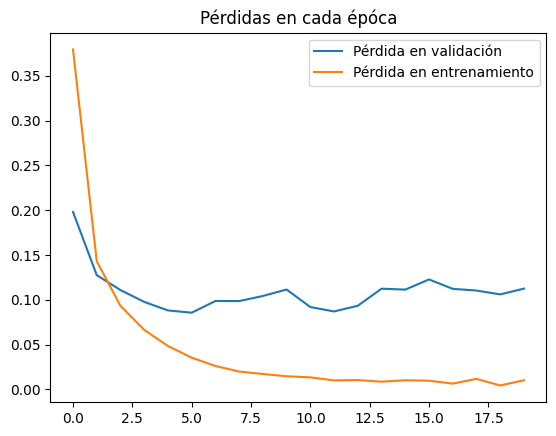

In [ ]:
import matplotlib.pyplot as plt

def graph_comparative(val_losses, train_losses):

    plt.figure()
    plt.plot(val_losses, label = "Pérdida en validación")
    plt.plot(train_losses, label = "Pérdida en entrenamiento")
    plt.legend()
    plt.title("Pérdidas en cada épóca")
    plt.show()

graph_comparative(val_losses, train_losses)

### Segunda red

In [18]:
net_structure = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 64),
    nn.LeakyReLU(),
    nn.Linear(64, 128),
    nn.Tanh(),
    nn.Linear(128, 256),
    nn.Sigmoid(),
    nn.Linear(256, 10)
)

model2 = classifier(net_structure).to(device)


In [19]:
optmizer = optim.Adam(model2.parameters(), lr = 0.01)
train_losses =[]
val_losses = []

train(model2, nn.CrossEntropyLoss(), optmizer, train_losses, val_losses )

Epoch [1/20], Loss: 0.3360
Epoch [2/20], Loss: 0.2107
Epoch [3/20], Loss: 0.2056
Epoch [4/20], Loss: 0.2180
Epoch [5/20], Loss: 0.2332
Epoch [6/20], Loss: 0.2311
Epoch [7/20], Loss: 0.2630
Epoch [8/20], Loss: 0.2512
Epoch [9/20], Loss: 0.2354
Epoch [10/20], Loss: 0.2756
Epoch [11/20], Loss: 0.2373
Epoch [12/20], Loss: 0.2889
Epoch [13/20], Loss: 0.2960
Epoch [14/20], Loss: 0.2700
Epoch [15/20], Loss: 0.2689
Epoch [16/20], Loss: 0.2508
Epoch [17/20], Loss: 0.2268
Epoch [18/20], Loss: 0.2519
Epoch [19/20], Loss: 0.2550
Epoch [20/20], Loss: 0.2711


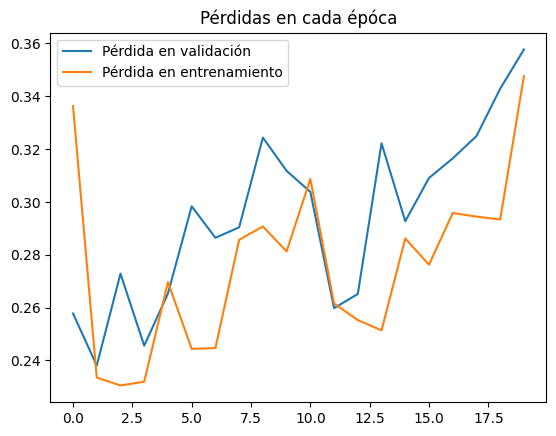

In [ ]:
graph_comparative(val_losses, train_losses)

### Tercera Red

In [20]:
net_structure = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 512),
    nn.Sigmoid(),
    nn.Linear(512, 256),
    nn.Tanh(),
    nn.Linear(256, 128),
    nn.LeakyReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.Sigmoid(),
    nn.Linear(32, 16),
    nn.Tanh(),
    nn.Linear(16,10)
)
model3 = classifier(net_structure).to(device=device)

optmizer = optim.Adam(model3.parameters(), lr = 0.005)
train_losses =[]
val_losses = []

train(model3, nn.CrossEntropyLoss(), optmizer, train_losses, val_losses )

Epoch [1/20], Loss: 0.7244
Epoch [2/20], Loss: 0.4045
Epoch [3/20], Loss: 0.3895
Epoch [4/20], Loss: 0.3899
Epoch [5/20], Loss: 0.4024
Epoch [6/20], Loss: 0.4417
Epoch [7/20], Loss: 0.4345
Epoch [8/20], Loss: 0.4335
Epoch [9/20], Loss: 0.4244
Epoch [10/20], Loss: 0.4385
Epoch [11/20], Loss: 0.4581
Epoch [12/20], Loss: 0.4535
Epoch [13/20], Loss: 0.5492
Epoch [14/20], Loss: 0.5030
Epoch [15/20], Loss: 0.5677
Epoch [16/20], Loss: 0.5937
Epoch [17/20], Loss: 0.6378
Epoch [18/20], Loss: 0.5926
Epoch [19/20], Loss: 0.6182
Epoch [20/20], Loss: 0.5839


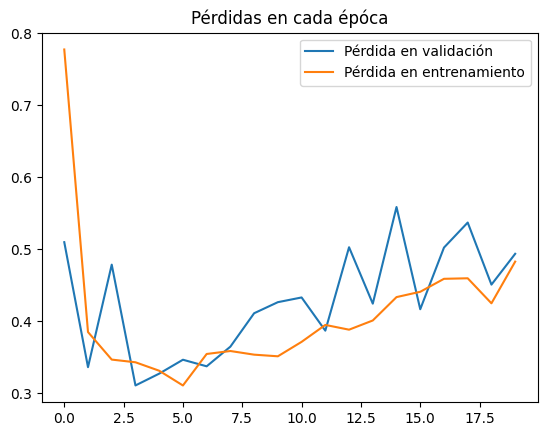

In [ ]:
graph_comparative(val_losses, train_losses)

## Tuning de Hiperparámetros

Como podemos ver de todas la primera fue la que mejor le fue para poder generalizar los datos ,las otras no seguian una tendencia clara y habia muchas irregularidades demostrando que no aprendia nada el modelo.


Asi que dado eso vamos a instalar bayesian optimization para poder tunnear el modelo

In [4]:
!pip install bayesian-optimization --quiet


Hacemos las importaciones

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from bayes_opt import BayesianOptimization

Definimos el modelo

In [6]:
class Classifier(nn.Module):
    def __init__(self, hidden1, hidden2, activation_fn):
        super(Classifier, self).__init__()
        activations = {
            'relu': nn.ReLU(),
            'sigmoid': nn.Sigmoid(),
            'tanh': nn.Tanh()
        }
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, hidden1),
            activations[activation_fn],
            nn.Linear(hidden1, hidden2),
            activations[activation_fn],
            nn.Linear(hidden2, 10)
        )

    def forward(self, x):
        return self.model(x)


Definimos la funcion de train

In [7]:
def train_and_validate(hidden1, hidden2, lr, activation):
    hidden1 = int(hidden1)
    hidden2 = int(hidden2)
    activation = ['relu', 'sigmoid', 'tanh'][int(activation)]

    model = Classifier(hidden1, hidden2, activation).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_function = nn.CrossEntropyLoss()

    for epoch in range(5):  # pocas épocas para tuning rápido
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()

    # Evaluar en validación
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    print(f"[Tuning] hidden1={hidden1}, hidden2={hidden2}, lr={lr:.5f}, act={activation} -> acc={accuracy:.4f}")
    return accuracy

### Bayesian Optimization

Hacemos uso de la optimizacon por bayesianas

In [8]:
pbounds = {
    'hidden1': (64, 512),
    'hidden2': (32, 256),
    'lr': (0.0001, 0.01),
    'activation': (0, 2)
}

optimizer_bo = BayesianOptimization(
    f=train_and_validate,
    pbounds=pbounds,
    random_state=42
)

optimizer_bo.maximize(init_points=3, n_iter=5)

# ====== 6. MEJOR CONFIGURACIÓN ======
print("Mejor configuración encontrada:", optimizer_bo.max)

|   iter    |  target   |  hidden1  |  hidden2  |    lr     | activa... |
-------------------------------------------------------------------------
[Tuning] hidden1=231, hidden2=244, lr=0.00735, act=sigmoid -> acc=0.9565
| 1         | 0.9565    | 231.79397 | 244.96000 | 0.0073467 | 1.1973169 |
[Tuning] hidden1=133, hidden2=66, lr=0.00068, act=sigmoid -> acc=0.9619
| 2         | 0.9619166 | 133.89635 | 66.942772 | 0.0006750 | 1.7323522 |
[Tuning] hidden1=333, hidden2=190, lr=0.00030, act=sigmoid -> acc=0.9623
| 3         | 0.96225   | 333.29952 | 190.60825 | 0.0003037 | 1.9398197 |
[Tuning] hidden1=331, hidden2=190, lr=0.00456, act=sigmoid -> acc=0.9671
| 4         | 0.9670833 | 331.96962 | 190.21239 | 0.0045618 | 1.3748247 |
[Tuning] hidden1=331, hidden2=189, lr=0.00560, act=sigmoid -> acc=0.9607
| 5         | 0.9606666 | 331.50910 | 189.60159 | 0.0055975 | 1.1402501 |
[Tuning] hidden1=165, hidden2=229, lr=0.00910, act=relu -> acc=0.9529
| 6         | 0.9529166 | 165.89328 | 229.78119 

Podemos ver que el mejor odelo eleigio como capa oculta 1 331 , capa oculta 2 como 190 , lr como 0.004 y sigboide como activacion, asi que ahora entrenamos ese modelo

In [9]:
best_params = optimizer_bo.max['params']
hidden1 = int(best_params['hidden1'])
hidden2 = int(best_params['hidden2'])
activation = ['relu', 'sigmoid', 'tanh'][int(best_params['activation'])]
lr = best_params['lr']

model = Classifier(hidden1, hidden2, activation).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)
loss_function = nn.CrossEntropyLoss()

epochs = 10
train_losses, val_losses = [], []


for epoch in range(epochs):
    model.train()
    running_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_losses.append(running_loss / len(train_loader))

    # Validación
    model.eval()
    running_loss = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_function(outputs, labels)
            running_loss += loss.item()
    val_losses.append(running_loss / len(val_loader))
    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_losses[-1]:.4f} - Val Loss: {val_losses[-1]:.4f}")




Epoch [1/10] - Train Loss: 0.2718 - Val Loss: 0.1677
Epoch [2/10] - Train Loss: 0.1343 - Val Loss: 0.1481
Epoch [3/10] - Train Loss: 0.1080 - Val Loss: 0.1239
Epoch [4/10] - Train Loss: 0.0907 - Val Loss: 0.1265
Epoch [5/10] - Train Loss: 0.0855 - Val Loss: 0.1148
Epoch [6/10] - Train Loss: 0.0786 - Val Loss: 0.1306
Epoch [7/10] - Train Loss: 0.0745 - Val Loss: 0.1143
Epoch [8/10] - Train Loss: 0.0727 - Val Loss: 0.0985
Epoch [9/10] - Train Loss: 0.0598 - Val Loss: 0.1062
Epoch [10/10] - Train Loss: 0.0608 - Val Loss: 0.1199


Ahora lo graficamos

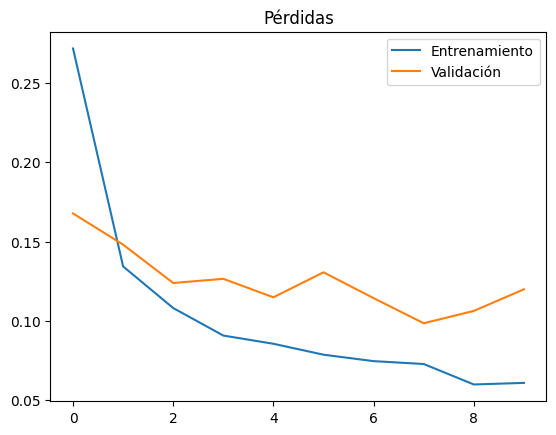

In [10]:
import matplotlib.pyplot as plt
plt.plot(train_losses, label="Entrenamiento")
plt.plot(val_losses, label="Validación")
plt.legend()
plt.title("Pérdidas")
plt.show()

Como podemos ver ahora si vemos una clara tendencia es mas se puede ver que ahora ya no hay tanta variacion como al inicio indicando que tenemos un buen modelo.

## Evaluación del Modelo:

Ahora evaluaremos su desempeño

In [21]:
import torch

def evaluate_accuracy(model, data_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total



models = {
    "Modelo 1": model_1.to(device),
    "Modelo 2": model2.to(device),
    "Modelo 3": model3.to(device),
    "Modelo con Tunning": model.to(device),
}

accuracies = {}

for name, model in models.items():
    acc = evaluate_accuracy(model, test_loader, device)
    accuracies[name] = acc
    print(f"{name} Accuracy en test: {acc:.4f}")

print("\nRanking de modelos según accuracy en test:")
sorted_models = sorted(accuracies.items(), key=lambda x: x[1], reverse=True)

print("Modelo\t\tAccuracy")
for name, acc in sorted_models:
    print(f"{name}\t\t{acc:.4f}")


Modelo 1 Accuracy en test: 0.0863
Modelo 2 Accuracy en test: 0.9128
Modelo 3 Accuracy en test: 0.8568
Modelo con Tunning Accuracy en test: 0.9683

Ranking de modelos según accuracy en test:
Modelo		Accuracy
Modelo con Tunning		0.9683
Modelo 2		0.9128
Modelo 3		0.8568
Modelo 1		0.0863


Podemos ver que todos los modelos el mejor fue el de tunning, e increiblemente el 2 y el 3 a pesar de variar mucho en su funcion de perdida, tuvieron un mejor desempeño que el primero. Indicando que lograron aprender cosas bastante utiles. A pesar de todo ello el hacer uso de la implementacion de bayesian optimization si ayudo ya que trato de encontrar como lograr minimizar los pesos sin caer en minimos locales o hacerlo de manera aleatoria


> ¿Qué hiperparámetros influyeron más en la mejora del rendimiento del
modelo? ¿Por qué?

Lo que vemos que afecto su rendimiento fue el uso de diferentes capas, y tambien de las diferentes neuronas entre capas. Si se puede observar la red 2 y la red 3 emplearon uso de muchas mas capas y eliminando linealidad integrando capas con funciones de activacion como tangente hiperbolica, leaky relu, y singoide, esto se puede ver ya que la primera red es una red mucho mas sencilla de solo 2 capas ocultas lo que hizo que no encontrara relacions mas profundas

Al utilizar bayesian optimization, se puede observar de que se mejoro mucho el desempeño , ya que esta fue cambiando no el numero de capas sino su cantidad de neuronas, encontrando un balance. Dando como resultado un buen acurrancy, pero siempre siendo mucho mas de las neuronas puestas en el primer modelo


